In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("cleaned_reviews.csv", low_memory=False)
print(f"전체 리뷰: {len(df):,}건\n")

# (1) 평점(별점) 분포
print("[평점 분포]")
print(df['평점'].value_counts(dropna=False).sort_index())
print(f"\n평점 NaN: {df['평점'].isna().sum():,}건")

# (2) 만족도 응답 여부
print("\n[만족도 응답 여부]")
print(df['만족도_응답여부'].value_counts())
print(f"\n→ 항목별 점수가 있는 리뷰: {(df['만족도_응답여부']=='응답').sum():,}건")

# (3) 평점과 만족도 응답의 교차표
print("\n[평점 × 만족도 응답 교차표]")
print(pd.crosstab(df['평점'], df['만족도_응답여부'], margins=True))

전체 리뷰: 685,292건

[평점 분포]
평점
1.0      1758
2.0      2241
3.0     17816
4.0     95314
5.0    566083
NaN      2080
Name: count, dtype: int64

평점 NaN: 2,080건

[만족도 응답 여부]
만족도_응답여부
미응답    666638
응답      18654
Name: count, dtype: int64

→ 항목별 점수가 있는 리뷰: 18,654건

[평점 × 만족도 응답 교차표]
만족도_응답여부     미응답     응답     All
평점                             
1.0         1690     68    1758
2.0         2155     86    2241
3.0        17084    732   17816
4.0        92988   2326   95314
5.0       550641  15442  566083
All       664558  18654  683212


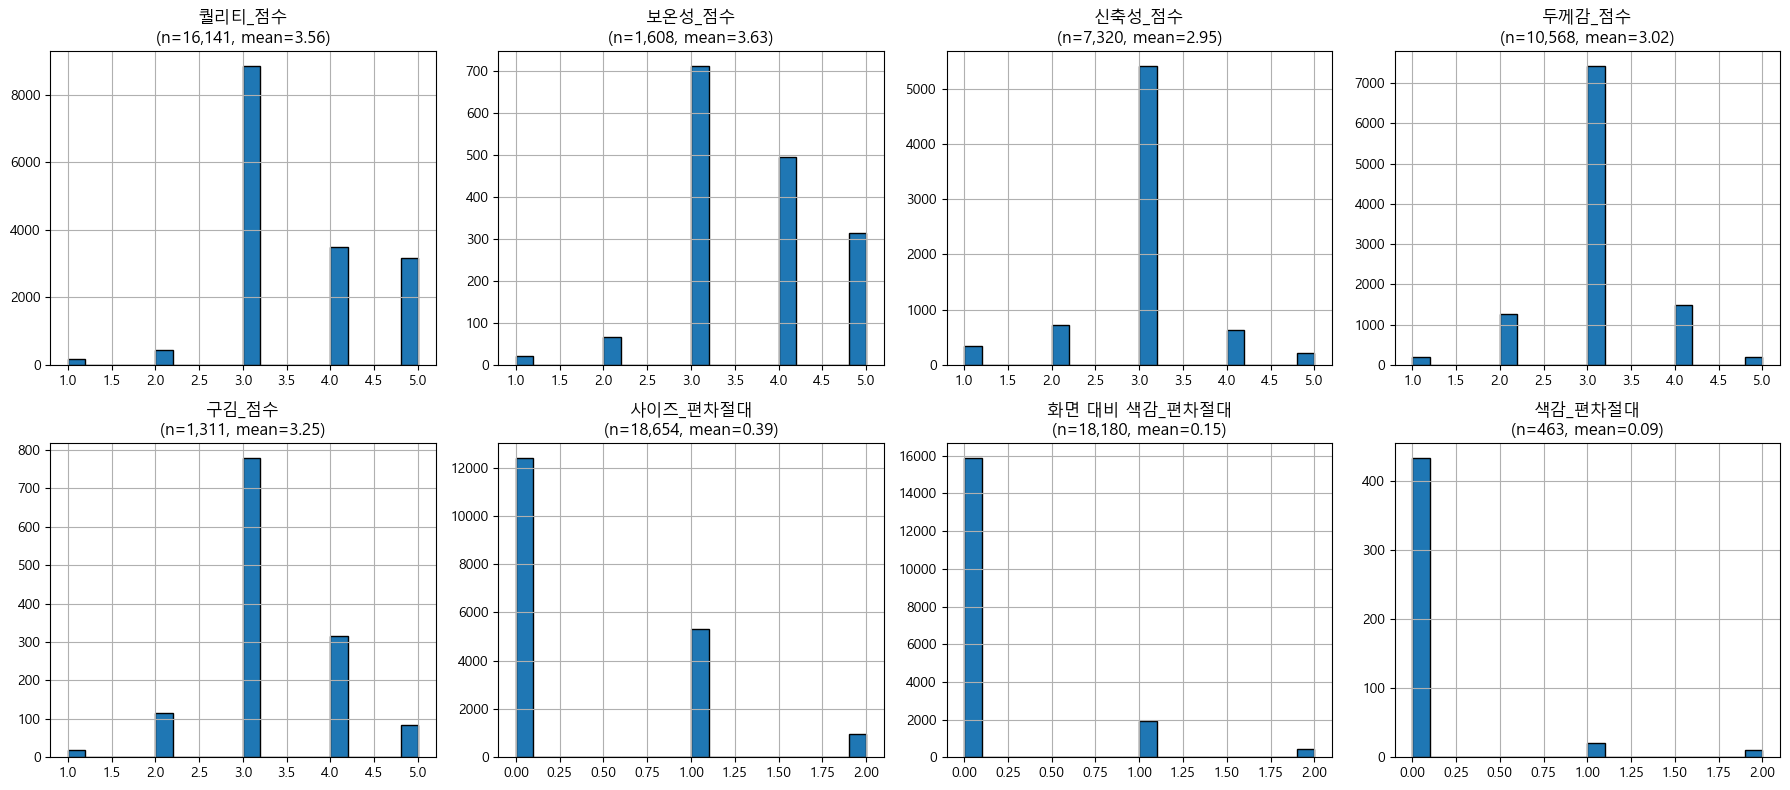

[항목별 점수 통계 - 1~5점, 높을수록 좋음]
         퀄리티_점수   보온성_점수   신축성_점수    두께감_점수    구김_점수
count  16141.00  1608.00  7320.00  10568.00  1311.00
mean       3.56     3.63     2.95      3.02     3.25
std        0.87     0.89     0.70      0.64     0.76
min        1.00     1.00     1.00      1.00     1.00
25%        3.00     3.00     3.00      3.00     3.00
50%        3.00     4.00     3.00      3.00     3.00
75%        4.00     4.00     3.00      3.00     4.00
max        5.00     5.00     5.00      5.00     5.00

[편차 절대값 통계 - 0~2, 0에 가까울수록 이상적]
       사이즈_편차절대  화면 대비 색감_편차절대  색감_편차절대
count  18654.00       18180.00   463.00
mean       0.39           0.15     0.09
std        0.58           0.42     0.35
min        0.00           0.00     0.00
25%        0.00           0.00     0.00
50%        0.00           0.00     0.00
75%        1.00           0.00     0.00
max        2.00           2.00     2.00


In [3]:
score_cols = ['퀄리티_점수', '보온성_점수', '신축성_점수', '두께감_점수', '구김_점수']
deviation_abs_cols = ['사이즈_편차절대', '화면 대비 색감_편차절대', '색감_편차절대']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(score_cols + deviation_abs_cols):
    if col in df.columns:
        df[col].dropna().hist(ax=axes[i], bins=20, edgecolor='black')
        axes[i].set_title(f'{col}\n(n={df[col].notna().sum():,}, mean={df[col].mean():.2f})')

plt.tight_layout()
plt.show()

# 항목별 점수 종합 통계
print("[항목별 점수 통계 - 1~5점, 높을수록 좋음]")
print(df[score_cols].describe().round(2))

print("\n[편차 절대값 통계 - 0~2, 0에 가까울수록 이상적]")
print(df[deviation_abs_cols].describe().round(2))

In [4]:
# 모든 항목별 신호를 하나의 종합 점수로 합치기
# - 점수형(1~5)은 그대로
# - 편차절대(0~2)는 5점 만점으로 역변환: 5 - (편차절대 * 2.5)

def make_consensus_score(row):
    scores = []
    
    # 평점 자체 (가장 강한 신호)
    if pd.notna(row['평점']):
        scores.append(('평점', row['평점']))
    
    # 점수형 컬럼 (1~5)
    for col in ['퀄리티_점수', '보온성_점수', '신축성_점수', '두께감_점수', '구김_점수']:
        if pd.notna(row[col]):
            scores.append((col, row[col]))
    
    # 편차절대 컬럼 (0~2 → 1~5로 변환, 편차 작을수록 좋음)
    for col in ['사이즈_편차절대', '화면 대비 색감_편차절대', '색감_편차절대']:
        if pd.notna(row[col]):
            converted = 5 - (row[col] * 2)  # 0→5, 1→3, 2→1
            scores.append((col, converted))
    
    if len(scores) == 0:
        return np.nan, 0
    avg = np.mean([s[1] for s in scores])
    return avg, len(scores)

# 시간 좀 걸려요 (685K건 × apply)
result = df.apply(make_consensus_score, axis=1, result_type='expand')
df['종합점수'] = result[0]
df['신호개수'] = result[1]

print(f"[종합점수 분포]")
print(df['종합점수'].describe().round(2))

# weak label 후보 만들기
def to_weak_label(row):
    rating = row['평점']
    consensus = row['종합점수']
    n_signals = row['신호개수']
    
    if pd.isna(rating):
        return 'unknown'
    
    # 케이스 분류
    if rating >= 4 and consensus >= 4:
        return 'confident_positive'  # 확실한 긍정
    elif rating <= 2 and consensus <= 2.5:
        return 'confident_negative'  # 확실한 부정
    elif rating == 3:
        return 'neutral'
    elif rating >= 4 and consensus < 3:
        return 'mismatch_high_low'   # 평점 좋은데 항목 나쁨 (의심)
    elif rating <= 2 and consensus > 3:
        return 'mismatch_low_high'   # 평점 나쁜데 항목 좋음 (의심)
    else:
        return 'ambiguous'

df['weak_label'] = df.apply(to_weak_label, axis=1)
print("\n[weak label 분포]")
print(df['weak_label'].value_counts())
print(f"\n학습에 안전하게 쓸 수 있는 데이터: "
      f"{df['weak_label'].isin(['confident_positive','confident_negative']).sum():,}건")

[종합점수 분포]
count    683212.00
mean          4.77
std           0.53
min           1.00
25%           5.00
50%           5.00
75%           5.00
max           5.00
Name: 종합점수, dtype: float64

[weak label 분포]
weak_label
confident_positive    656948
neutral                17816
ambiguous               4277
confident_negative      3874
unknown                 2080
mismatch_high_low        237
mismatch_low_high         60
Name: count, dtype: int64

학습에 안전하게 쓸 수 있는 데이터: 660,822건
